Saving Pakistan Air Quality & Weather Data (2021–2024).zip to Pakistan Air Quality & Weather Data (2021–2024).zip
Files extracted: ['Testing', 'Training']
Dataset shape: (123134, 18)
aqi_label
Unhealthy    56259
Moderate     36202
Hazardous    22415
Good          8258
Name: count, dtype: int64


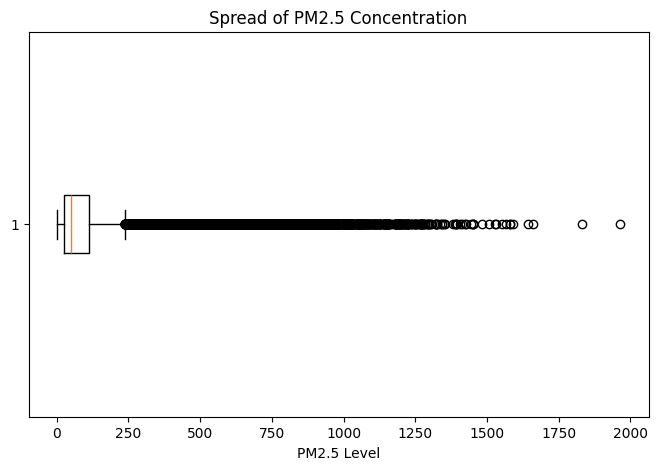

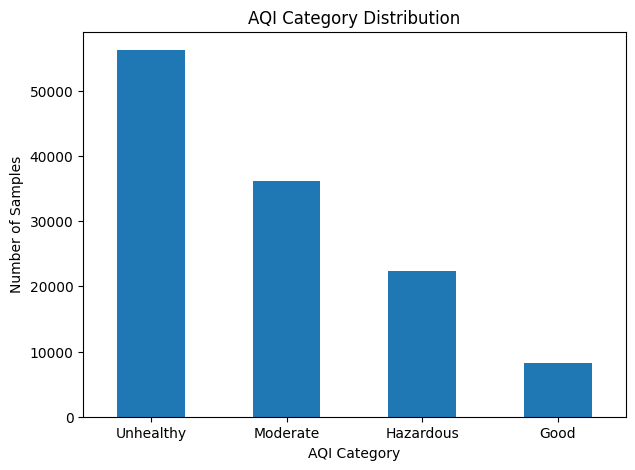

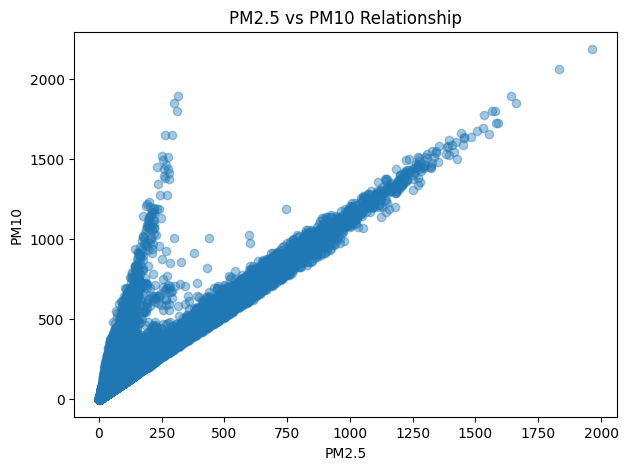

Label Mapping:
{'Good': np.int64(0), 'Hazardous': np.int64(1), 'Moderate': np.int64(2), 'Unhealthy': np.int64(3)}
Logistic Regression trained successfully
Random Forest trained successfully


In [ ]:
from google.colab import files
import zipfile
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

uploaded_files = files.upload()
zip_file_name = list(uploaded_files.keys())[0]

with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall("air_quality_data")

print("Files extracted:", os.listdir("air_quality_data"))
csv_file_path = "air_quality_data/Training/concatenated_dataset_Aug_2021_to_July_2024.csv"
data = pd.read_csv(csv_file_path)
print("Dataset shape:", data.shape)
data.head()
data.columns = data.columns.str.strip().str.replace(" ", "_").str.lower()
def categorize_aqi(pm25):
    if pm25 <= 12:
        return "Good"
    elif pm25 <= 35.4:
        return "Moderate"
    elif pm25 <= 150.4:
        return "Unhealthy"
    else:
        return "Hazardous"

data["aqi_label"] = data["components_pm2_5"].apply(categorize_aqi)
print(data["aqi_label"].value_counts())
numeric_cols = data.select_dtypes(include=np.number).columns
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].median())

plt.figure(figsize=(8,5))
plt.boxplot(data["components_pm2_5"], vert=False)
plt.title("Spread of PM2.5 Concentration")
plt.xlabel("PM2.5 Level")
plt.show()
plt.figure(figsize=(7,5))
data["aqi_label"].value_counts().plot(kind="bar")
plt.title("AQI Category Distribution")
plt.xlabel("AQI Category")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.show()
plt.figure(figsize=(7,5))
plt.scatter(
    data["components_pm2_5"],
    data["components_pm10"],
    alpha=0.4
)
plt.title("PM2.5 vs PM10 Relationship")
plt.xlabel("PM2.5")
plt.ylabel("PM10")
plt.show()
data["total_pm"] = data["components_pm2_5"] + data["components_pm10"]
data["total_gases"] = (
    data["components_no2"] +
    data["components_so2"] +
    data["components_o3"]
)
for col in ["components_pm2_5", "components_pm10"]:
    upper_limit = data[col].quantile(0.99)
    data[col] = np.clip(data[col], None, upper_limit)
target = "aqi_label"
features = data.drop(columns=[target, "datetime"])
labels = data[target]

features = features.select_dtypes(include=np.number)

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)

print("Label Mapping:")
print(dict(zip(label_encoder.classes_,
               label_encoder.transform(label_encoder.classes_))))

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    scaled_features,
    encoded_labels,
    test_size=0.25,
    random_state=42,
    stratify=encoded_labels
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight="balanced"),
    "SVM": SVC(probability=True, class_weight="balanced")
}
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} trained successfully")

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

for name, model in models.items():
    preds = model.predict(X_test)
    print("\n==============================")
    print("Model:", name)
    print("Accuracy:", accuracy_score(y_test, preds))
    print("Confusion Matrix:\n", confusion_matrix(y_test, preds))
    print(classification_report(
        y_test, preds,
        target_names=label_encoder.classes_
    ))
rf_model = models["Random Forest"]

importance = pd.Series(
    rf_model.feature_importances_,
    index=features.columns
).sort_values()

plt.figure(figsize=(8,5))
importance.tail(10).plot(kind="barh")
plt.title("Top Influential Features for AQI Prediction")
plt.xlabel("Importance Score")
plt.show()
import joblib

joblib.dump(rf_model, "aqi_rf_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")

print("✅ Model, scaler, and label encoder saved successfully!")

# Air Quality Index (AQI) Prediction – Methodology & Explanation

## 1. Dataset Upload and Extraction
The dataset which is provided as a ZIP file containing air quality data collected between **August 2021 and July 2024**.  
The ZIP file is uploaded to Google Colab and extracted programmatically to ensure reproducibility and easy file handling.

**Why this approach?**
- It allows flexible dataset updates
- And keeps raw data organized
- It ensures compatibility with Colabed environment

---

## 2. Data Loading
The main CSV file is loaded by using the library **Pandas**, which provides efficient tools for handling large datasets.

We also inspect:
- Dataset shape (rows × columns)
- First few records (head)

This step ensure that data is loaded correct before further process.

---

## 3. Column Name Cleaning
Column names are standardize by:
- Removing extra spaces
- Replacing spaces with underscores
- Converting all names to lowercase

**Reason:**
- Mainly it improve readability
- Prevent errors during the feature selection
- Follow best practices for data science projects

---

## 4. AQI Category Creation (Target Variable)
AQI categories are created using **PM2.5 concentration levels**, following standard air quality thresholds:

| PM2.5 Range | AQI Label |
|------------|----------|
| ≤ 12       | Good |
| 12–35.4   | Moderate |
| 35.4–150.4| Unhealthy |
| > 150.4   | Hazardous |

I converts a continuous variable into a **multi-class classification problem**, which is interpretable for real-world applications.

---

## 5. Handling Missing Values
Only **numerical columns** are considered for imputation.  
Missing values are filled using the **median** of each column.

**Why median?**
- Robust to outliers
- Preserves distribution better than mean
- Suitable for environmental data

---

## 6. Exploratory Data Analysis (EDA)
EDA helps understand data distribution and relationships.

### Visualizations Used:
1. **Boxplot (PM2.5)**  
   - Identifies spread and extreme values
2. **Bar Chart (AQI Categories)**  
   - Shows class imbalance
3. **Scatter Plot (PM2.5 vs PM10)**  
   - Reveals correlation between particulate pollutants

These plots validate data quality and justify later modeling choices.

---

## 7. Feature Engineering
Two new features are created:

- **Total PM** = PM2.5 + PM10  
- **Total Gases** = NO₂ + SO₂ + O₃  

**Purpose:**
- Capture combined pollution effects
- Improve model learning capability
- Reduce reliance on individual pollutants only

---

## 8. Outlier Handling
Extreme values in PM2.5 and PM10 are capped at the **99th percentile** using clipping.

**Reason:**
- Prevents model bias
- Reduces noise from sensor errors
- Maintains most real-world variability

---

## 9. Feature and Target Separation
- **Target:** AQI category label  
- **Features:** All numerical pollutant variables  
- Datetime column is removed since it does not directly impact AQI classification.

---

## 10. Target Encoding
AQI labels are converted into numeric values using **Label Encoding**.

This is required because machine learning models work with numerical data.

---

## 11. Feature Scaling
All numerical features are standardized using **StandardScaler**.

**Why scaling?**
- Ensures equal feature contribution
- Improves convergence of Logistic Regression and SVM
- Prevents dominance of large-scale variables

---

## 12. Train–Test Split
The dataset is split into:
- **75% Training**
- **25% Testing**

Stratified splitting is used to maintain class balance across sets.

---

## 13. Model Selection and Training
Three classification models are trained:

1. **Logistic Regression**
   - Simple baseline model
   - Interpretable results
2. **Random Forest**
   - Handles non-linearity
   - Robust to noise
   - Provides feature importance
3. **Support Vector Machine (SVM)**
   - Effective for complex decision boundaries

Class imbalance is handled using `class_weight="balanced"`.

---

## 14. Model Evaluation
Each model is evaluated using:
- Accuracy
- Confusion Matrix
- Precision, Recall, and F1-score

This provides a **complete performance comparison**, not just accuracy.

---

## 15. Feature Importance Analysis
Random Forest feature importance is visualized to identify the **top 10 most influential features**.

**Insight:**
- Helps understand pollutant impact on AQI
- Improves model interpretability
- Useful for environmental policy analysis

---

## 16. Model Saving
The following objects are saved using `joblib`:
- Trained Random Forest model
- Feature scaler
- Label encoder

**Benefit:**
- Enables future predictions
- Supports deployment without retraining
- Ensures reproducibility

---

## Final Outcome
✔ A robust AQI classification pipeline  
✔ Multiple models compared  
✔ Interpretable results with feature importance  
✔ Ready-to-deploy trained model  

This system can assist in **air quality monitoring**, **early warnings**, and **environmental decision-making**.